In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime
from pathlib import Path
import cartopy.crs as ccrs                 # For plotting maps
import cartopy.feature as cfeature         # For plotting maps
from cartopy.util import add_cyclic_point  # For plotting maps
from sklearn.metrics import r2_score

In [2]:
#abline
def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')

In [3]:
# path to shawn's run:
result_dir_shawn = Path('/glade/campaign/acom/acom-climate/UTLS/shawnh/archive/FCnudged_f09.mam.mar27.2000_2021.001/atm/proc/tseries/month_1')

#Files to read in from Shawn's run:
files_to_open_shawn = ['FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.bc_a1.200101-202212.nc', 
                       'FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.bc_a4.200101-202212.nc',
                       'FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.CO.200101-202212.nc',
                       'FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.pom_a4.200101-202212.nc',
                       'FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.pom_a1.200101-202212.nc',
                       'FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.O3.200101-202212.nc',
                       'FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.TMQ.200101-202212.nc']
file_paths_shawn = [result_dir_shawn / filename for filename in files_to_open_shawn]
nc_load_shawn = xr.open_mfdataset(file_paths_shawn, combine='nested')
nc_load_shawn = nc_load_shawn[['TMQ', 'CO', 'O3', 'bc_a1', 'bc_a4', 'pom_a1', 'pom_a4']]

#rename vars
data_vars = [var for var in nc_load_shawn.data_vars]
variable_rename_mapping = {var: var + '_s' for var in data_vars}
nc_load_shawn = nc_load_shawn.rename(variable_rename_mapping)
nc_load_shawn

<xarray.Dataset>
Dimensions:   (time: 264, lat: 192, lon: 288, lev: 32)
Coordinates:
  * lat       (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev       (lev) float64 3.643 7.595 14.36 24.61 ... 936.2 957.5 976.3 992.6
  * time      (time) datetime64[ns] 2001-02-01 2001-03-01 ... 2023-01-01
Data variables:
    TMQ_s     (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    CO_s      (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    O3_s      (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    bc_a1_s   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    bc_a4_s   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    pom_a1_s  (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    pom_a4_s  (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.mar27.2000_2021.001
    logname:           tilmes
    host:              cheyenne3
    initial_file:      /glade/work/tilmes/inputdata/init/carma/f.e21.FWHISTBg...
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

In [4]:
#path to my run:
result_dir_atm = Path('/glade/derecho/scratch/demurray/archive/FCnudged_f09.mam.Murray.Mar18_02.2000_2021.001/atm/hist')

#Read in monthly files from current run (fincl1)
files_to_open = ['FCnudged_f09.mam.Murray.Mar18_02.2000_2021.001.cam.h0.2003-01.nc']
file_paths = [result_dir_atm / filename for filename in files_to_open]
nc_load_deni = xr.open_mfdataset(file_paths, combine='nested')
nc_load_deni = nc_load_deni[['TMQ', 'CO', 'O3', 'bc_a1', 'bc_a4', 'pom_a1', 'pom_a4']]

#rename vars
data_vars = [var for var in nc_load_deni.data_vars]
variable_rename_mapping = {var: var + '_d' for var in data_vars}
nc_load_deni = nc_load_deni.rename(variable_rename_mapping)
nc_load_deni

<xarray.Dataset>
Dimensions:   (time: 1, lat: 192, lon: 288, lev: 32)
Coordinates:
  * lat       (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev       (lev) float64 3.643 7.595 14.36 24.61 ... 936.2 957.5 976.3 992.6
  * time      (time) datetime64[ns] 2003-02-01
Data variables:
    TMQ_d     (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    CO_d      (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    O3_d      (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    bc_a1_d   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    bc_a4_d   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    pom_a1_d  (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    pom_a4_d  (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.Murray.Mar18_02.2000_2021.001
    logname:           demurray
    host:              derecho2
    initial_file:      /glade/campaign/acom/acom-climate/UTLS/shawnh/archive/...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

<xarray.DataArray 'bc_a4_s' (lat: 192, lon: 288)>
dask.array<getitem, shape=(192, 288), dtype=float32, chunksize=(96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    lev      float64 992.6
    time     datetime64[ns] 2003-02-01
Attributes:
    mdims:         1
    units:         kg/kg
    mixing_ratio:  dry
    long_name:     bc_a4 concentration
    cell_methods:  time: mean
(192, 288)
(192,)


/glade/u/home/demurray/.local/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/glade/u/home/demurray/.local/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


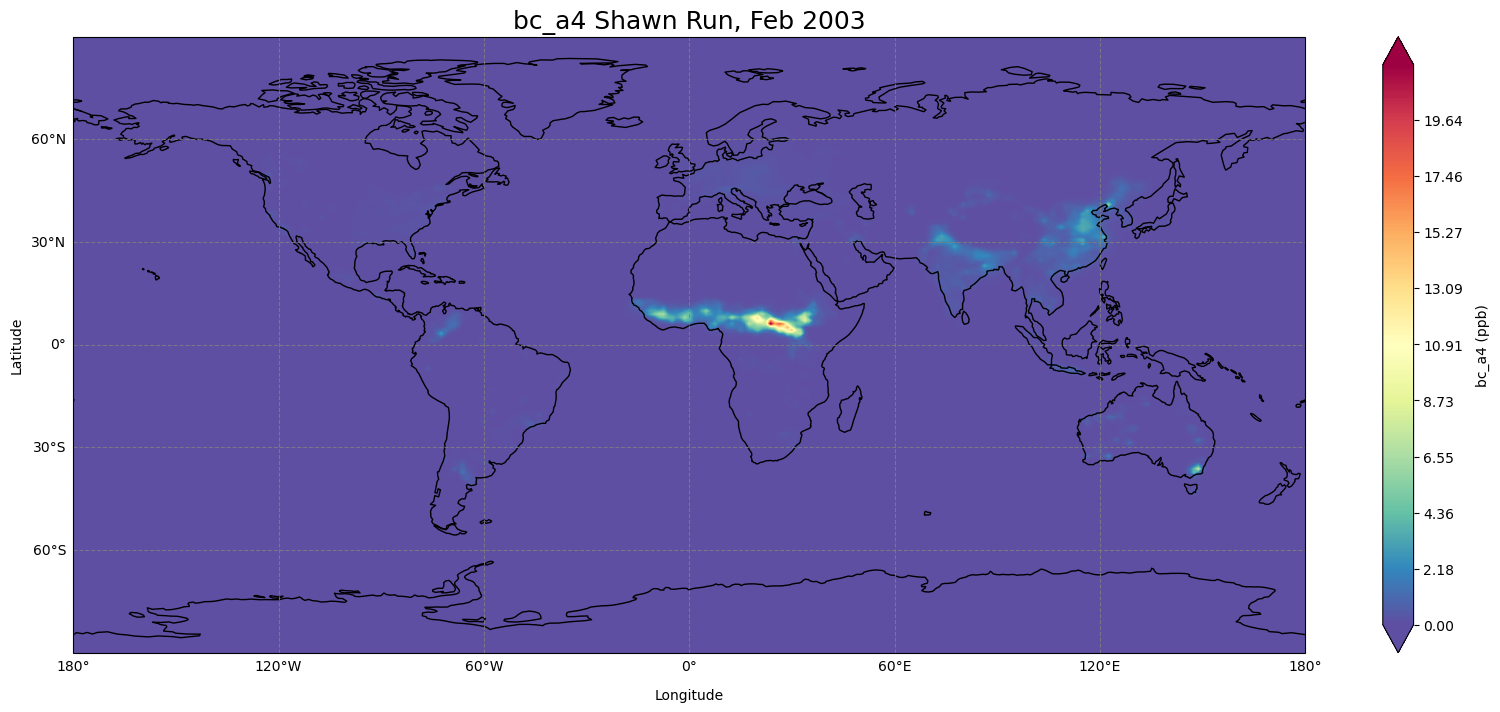

In [19]:
#Raw values maps:

#var_sel = nc_load_deni['bc_a4_d']
#var_srf = var_sel.isel(time=0, lev=31)
#var_srf = var_sel.isel(time=0)

var_sel = nc_load_shawn['bc_a4_s']
var_srf = var_sel.isel(time=24, lev= 31)

print(var_srf)

#select the variable at a specific time 
var_srf = var_srf*1e09 # 10-9 to ppb
print(var_srf.shape)

#extract grid variables
lat = var_srf.coords['lat']
lon = var_srf.coords['lon']
print(lat.shape)

var_srf_cyc, lon_cyc = add_cyclic_point(var_srf, coord=lon)

plt.figure(figsize=(20,8))

#Define projection
ax = plt.axes(projection=ccrs.PlateCarree())

#define contour levels
data_min = var_srf.min().values
data_max = var_srf.max().values
num_levels = 1000
clev = np.linspace(data_min, data_max, num_levels)
#clev = np.arange(-100,100,1)

#plot the data
plt.contourf(lon_cyc,lat,var_srf_cyc,clev,cmap='Spectral_r',extend='both')

# add coastlines
ax.add_feature(cfeature.COASTLINE)

#add lat lon grids
gl = ax.gridlines(draw_labels=True, color='grey', alpha=0.8, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# Titles
plt.title("bc_a4 Shawn Run, Feb 2003",fontsize=18)

# y-axis
ax.text(-0.04, 0.5, 'Latitude', va='bottom', ha='center', rotation='vertical', rotation_mode='anchor',transform=ax.transAxes)
# x-axis
ax.text(0.5, -0.08, 'Longitude', va='bottom', ha='center',rotation='horizontal', rotation_mode='anchor', transform=ax.transAxes)
# legend
ax.text(1.15, 0.5, 'bc_a4 (ppb)', va='bottom', ha='center',rotation='vertical', rotation_mode='anchor', transform=ax.transAxes)

plt.colorbar()
plt.show()

In [20]:
#Merge values from my run and shawn's run:
nc_all = xr.merge([nc_load_deni, nc_load_shawn], join = 'left')

#Create difference fields for each of the parameters:
nc_all['CO_diff'] = (nc_all['CO_s'] - nc_all['CO_d'])
nc_all['O3_diff'] = (nc_all['O3_s'] - nc_all['O3_d'])
nc_all['TMQ_diff'] = (nc_all['TMQ_s'] - nc_all['TMQ_d'])
nc_all['pom_a1_diff'] = (nc_all['pom_a1_s'] - nc_all['pom_a1_d'])
nc_all['pom_a4_diff'] = (nc_all['pom_a4_s'] - nc_all['pom_a4_d'])
nc_all['bc_a1_diff'] = (nc_all['bc_a1_s'] - nc_all['bc_a1_d'])
nc_all['bc_a4_diff'] = (nc_all['bc_a4_s'] - nc_all['bc_a4_d'])

#Create percent difference fields for each of the parameters:
nc_all['CO_perc_diff'] = ((nc_all['CO_s'] - nc_all['CO_d'])/nc_all['CO_d'])*100
nc_all['O3_perc_diff'] = ((nc_all['O3_s'] - nc_all['O3_d'])/nc_all['O3_d'])*100
nc_all['TMQ_perc_diff'] = ((nc_all['TMQ_s'] - nc_all['TMQ_d'])/nc_all['TMQ_d'])*100
nc_all['pom_a1_perc_diff'] = ((nc_all['pom_a1_s'] - nc_all['pom_a1_d'])/nc_all['pom_a1_d'])*100
nc_all['pom_a4_perc_diff'] = ((nc_all['pom_a4_s'] - nc_all['pom_a4_d'])/nc_all['pom_a4_d'])*100
nc_all['bc_a1_perc_diff'] = ((nc_all['bc_a1_s'] - nc_all['bc_a1_d'])/nc_all['bc_a1_d'])*100
nc_all['bc_a4_perc_diff'] = ((nc_all['bc_a4_s'] - nc_all['bc_a4_d'])/nc_all['bc_a4_d'])*100
nc_all

<xarray.Dataset>
Dimensions:           (lat: 192, lon: 288, lev: 32, time: 1)
Coordinates:
  * lat               (lat) float64 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon               (lon) float64 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev               (lev) float64 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * time              (time) datetime64[ns] 2003-02-01
Data variables: (12/28)
    TMQ_d             (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    CO_d              (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    O3_d              (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    bc_a1_d           (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    bc_a4_d           (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    pom_a1_d          (time, lev, lat, lon) float32 dask.array<chunksize=(1, 32, 192, 288), meta=np.ndarray>
    ...                ...
    O3_perc_diff      (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    TMQ_perc_diff     (time, lat, lon) float32 dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    pom_a1_perc_diff  (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    pom_a4_perc_diff  (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    bc_a1_perc_diff   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
    bc_a4_perc_diff   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 16, 96, 144), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.Murray.Mar18_02.2000_2021.001
    logname:           demurray
    host:              derecho2
    initial_file:      /glade/campaign/acom/acom-climate/UTLS/shawnh/archive/...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

<xarray.DataArray 'bc_a4_diff' (lat: 192, lon: 288)>
dask.array<getitem, shape=(192, 288), dtype=float32, chunksize=(96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    lev      float64 992.6
    time     datetime64[ns] 2003-02-01
(192, 288)
(192,)


/glade/u/home/demurray/.local/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/glade/u/home/demurray/.local/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


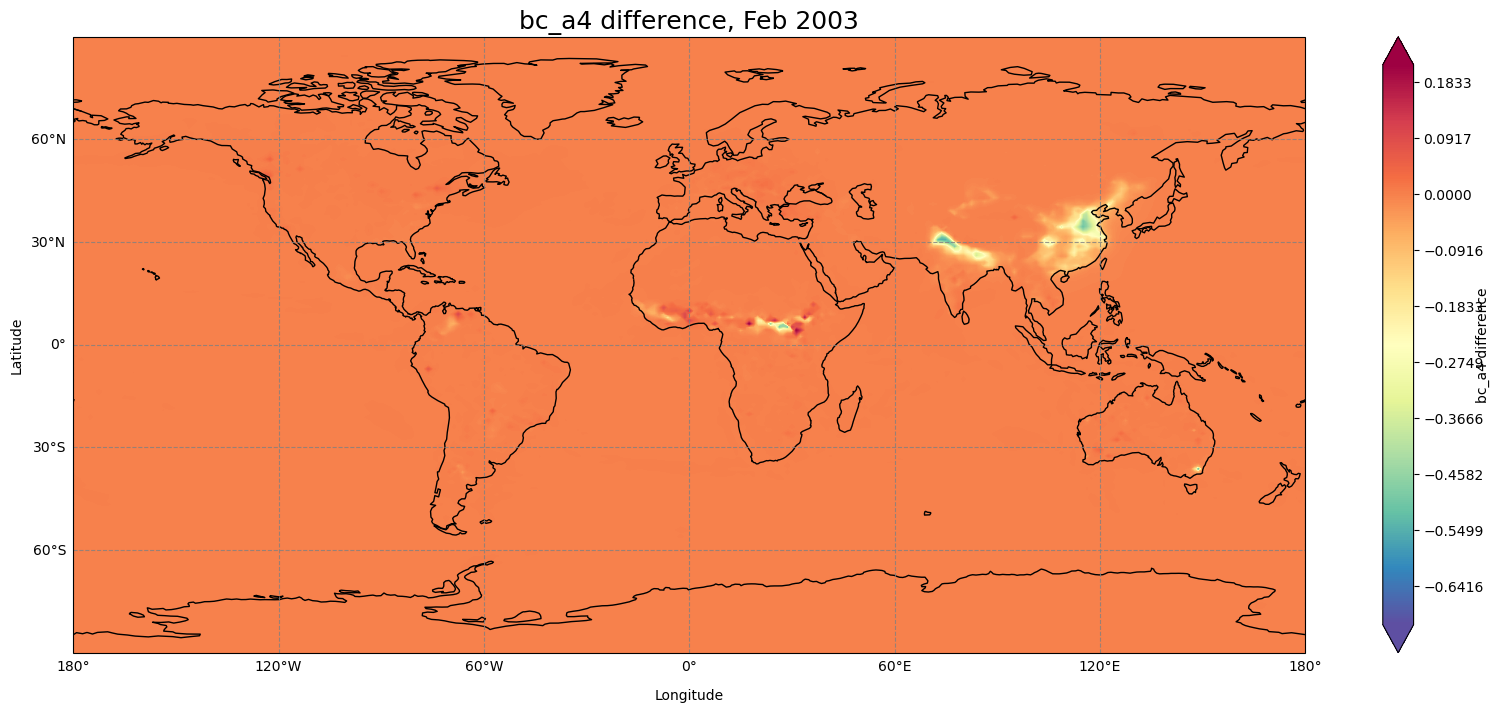

In [36]:
#Difference maps
var_sel = nc_all['bc_a4_diff']
#var_sel = nc_all['bc_a4_perc_diff']
var_srf = var_sel.isel(time=0, lev=31)

print(var_srf)

#select the variable at a specific time 
var_srf = var_srf*1e09 # 10-9 to ppb
print(var_srf.shape)

#extract grid variables
lat = var_srf.coords['lat']
lon = var_srf.coords['lon']
print(lat.shape)

var_srf_cyc, lon_cyc = add_cyclic_point(var_srf, coord=lon)

plt.figure(figsize=(20,8))

#Define projection
ax = plt.axes(projection=ccrs.PlateCarree())

#define contour levels
data_min = var_srf.min().values
data_max = var_srf.max().values
num_levels = 1000
clev = np.linspace(data_min, data_max, num_levels)
#clev = np.arange(-110,110,.1)

#plot the data
plt.contourf(lon_cyc,lat,var_srf_cyc,clev,cmap='Spectral_r',extend='both')

# add coastlines
ax.add_feature(cfeature.COASTLINE)

#add lat lon grids
gl = ax.gridlines(draw_labels=True, color='grey', alpha=0.8, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

# Titles
plt.title("bc_a4 difference, Feb 2003",fontsize=18)

# y-axis
ax.text(-0.04, 0.5, 'Latitude', va='bottom', ha='center', rotation='vertical', rotation_mode='anchor',transform=ax.transAxes)
# x-axis
ax.text(0.5, -0.08, 'Longitude', va='bottom', ha='center',rotation='horizontal', rotation_mode='anchor', transform=ax.transAxes)
# legend
ax.text(1.15, 0.5, 'bc_a4 difference', va='bottom', ha='center',rotation='vertical', rotation_mode='anchor', transform=ax.transAxes)

plt.colorbar()
plt.show()

In [37]:
#convert to dataframe
nc_df = nc_all.to_dataframe().reset_index()
nc_df = nc_df.loc[nc_df.lev == nc_df.lev.max(),]
nc_df.head(10)

,lat,lon,lev,time,TMQ_d,CO_d,O3_d,bc_a1_d,bc_a4_d,pom_a1_d,...,pom_a4_diff,bc_a1_diff,bc_a4_diff,CO_perc_diff,O3_perc_diff,TMQ_perc_diff,pom_a1_perc_diff,pom_a4_perc_diff,bc_a1_perc_diff,bc_a4_perc_diff
31,-90.0,0.00,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312164e-14,6.030772e-13,...,-1.839685e-14,4.152061e-15,-2.799137e-15,3.844299,-6.001028,0.582464,3.733376,-12.919497,3.419355,-12.106138
63,-90.0,1.25,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312164e-14,6.030772e-13,...,-1.839686e-14,4.152074e-15,-2.799142e-15,3.844299,-6.001028,0.582464,3.733385,-12.919506,3.419367,-12.106158
95,-90.0,2.50,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312164e-14,6.030772e-13,...,-1.839686e-14,4.152074e-15,-2.799142e-15,3.844299,-6.001028,0.582464,3.733385,-12.919506,3.419367,-12.106158
127,-90.0,3.75,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312163e-14,6.030773e-13,...,-1.839682e-14,4.152061e-15,-2.799132e-15,3.844299,-6.001028,0.582464,3.733366,-12.919481,3.419355,-12.106119
159,-90.0,5.00,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312164e-14,6.030772e-13,...,-1.839685e-14,4.152074e-15,-2.799137e-15,3.844299,-6.001028,0.582464,3.733385,-12.919497,3.419367,-12.106138
191,-90.0,6.25,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312163e-14,6.030772e-13,...,-1.839682e-14,4.152061e-15,-2.799132e-15,3.844299,-6.001028,0.582464,3.733376,-12.919481,3.419355,-12.106119
223,-90.0,7.50,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312163e-14,6.030773e-13,...,-1.839682e-14,4.152061e-15,-2.799134e-15,3.844299,-6.001028,0.582464,3.733366,-12.919481,3.419355,-12.106126
255,-90.0,8.75,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312163e-14,6.030772e-13,...,-1.839681e-14,4.152061e-15,-2.799132e-15,3.844299,-6.001028,0.582464,3.733376,-12.919472,3.419355,-12.106119
287,-90.0,10.00,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312164e-14,6.030772e-13,...,-1.839684e-14,4.152061e-15,-2.799137e-15,3.844299,-6.001028,0.582464,3.733376,-12.919490,3.419355,-12.106138
319,-90.0,11.25,992.556095,2003-02-01,0.975294,3.887368e-08,2.427935e-08,1.214282e-13,2.312164e-14,6.030772e-13,...,-1.839685e-14,4.152061e-15,-2.799137e-15,3.844299,-6.001028,0.582464,3.733376,-12.919497,3.419355,-12.106138


In [38]:
def plot_two_panel(x, y, hist_data, x_label='', y_label='', title='', hist_xlabel='', hist_ylabel='', hist_title=''):
    # Calculate R2 score
    r2 = r2_score(y, x)

    # Create the scatter plot with 1:1 line
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    # Plot 1 - Scatter plot
    axs[0].scatter(x, y, c='black', alpha=0.1)
    axs[0].set_xlabel(x_label)
    axs[0].set_ylabel(y_label)
    axs[0].set_title(title)
    axs[0].text(axs[0].get_xlim()[0], axs[0].get_ylim()[1], f'R2 = {r2:.2f}', ha='left', va='top', fontsize=12)
    axs[0].plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color='red')
    # Add the 1:1 line
    axs[0].plot(axs[0].get_xlim(), axs[0].get_xlim(), color='blue', linestyle='--')

    # Plot 2 - Histogram
    counts, bins, _ = axs[1].hist(hist_data, bins=100)
    axs[1].hist(hist_data, bins=100)
    axs[1].set_xlabel(hist_xlabel)
    axs[1].set_ylabel(hist_ylabel)
    axs[1].set_title(hist_title)
    
    # Add vertical line at 0
    axs[1].axvline(x=0, color='black', linestyle='--')

    # Find the mode (value with highest frequency) in the histogram data
    mode_index = np.argmax(counts)
    mode_x = (bins[mode_index] + bins[mode_index + 1]) / 2  # Midpoint of the bin with highest frequency
    axs[1].axvline(x=mode_x, color='red', linestyle='--')  # Add vertical line at mode
    axs[1].text(mode_x, max(counts), f'{mode_x:.2f}', ha='left', va='top', color='red', fontsize=12)  # Label the line with mode_x

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()

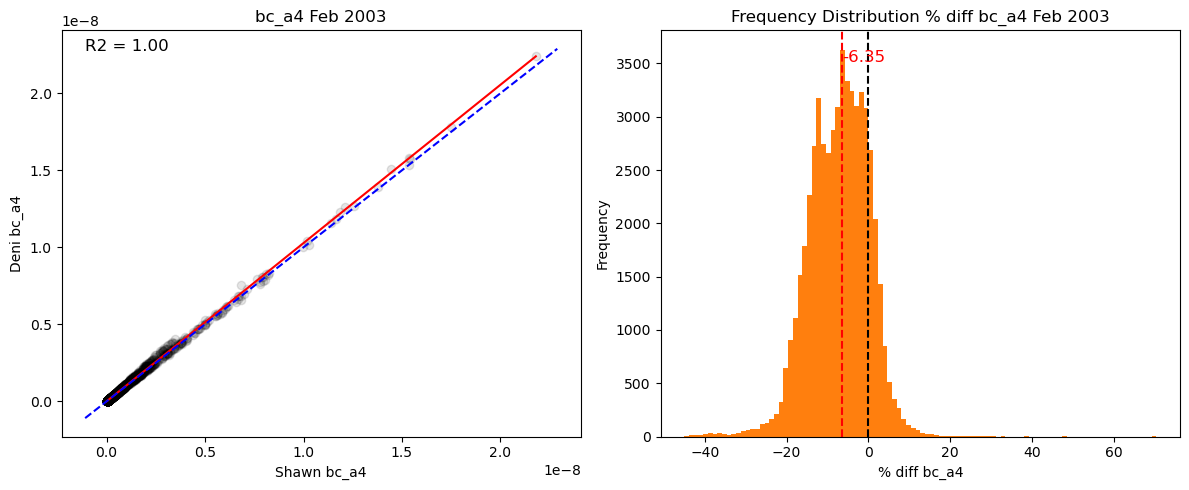

In [45]:
#plot_two_panel(x, y, hist_data, x_label='', y_label='', title='', hist_xlabel='', hist_ylabel='', hist_title='')
plot_two_panel(nc_df['bc_a4_s'], nc_df['bc_a4_d'], nc_df['bc_a4_perc_diff'], 
               x_label="Shawn bc_a4", y_label="Deni bc_a4", title="bc_a4 Feb 2003", 
               hist_xlabel="% diff bc_a4", hist_ylabel="Frequency", hist_title="Frequency Distribution % diff bc_a4 Feb 2003")